# ML: Non-Linear Regression — Logarithmic

When each successive unit of `x` adds *less* to `y` than the previous one — diminishing returns — a logarithmic curve fits cleanly.

## Theory
- https://en.wikipedia.org/wiki/Logarithmic_growth

## Equation
`y = a · ln(x) + b`

**Trick:** take `ln(x)` of the input, then fit a regular linear regression on `(ln(x), y)`. The fitted slope is `a`, the intercept is `b`. No special non-linear solver needed.

## Problem Statement — lot size vs price

A house's price increases with lot size, but the marginal value of each additional acre drops as lots get bigger — a buyer paying $620k for a 0.1-acre lot won't pay 50× that for a 5-acre version of the same house.

| lot_size (acres) | price ($k) |
| :--------------: | :--------: |
| 0.10 | 620  |
| 0.20 | 690  |
| 0.35 | 760  |
| 0.50 | 800  |
| 0.75 | 850  |
| 1.00 | 890  |
| 1.50 | 940  |
| 2.00 | 975  |
| 3.00 | 1020 |
| 5.00 | 1080 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

%matplotlib inline

In [2]:
data = {
    'lot_size': [0.10, 0.20, 0.35, 0.50, 0.75, 1.00, 1.50, 2.00, 3.00, 5.00],
    'price':    [620, 690, 760, 800, 850, 890, 940, 975, 1020, 1080],
}
test = {'lot_size': [0.25, 0.80, 2.50, 4.00]}

df = pd.DataFrame(data)
df

,lot_size,price
0,0.10,620
1,0.20,690
2,0.35,760
3,0.50,800
4,0.75,850
5,1.00,890
6,1.50,940
7,2.00,975
8,3.00,1020
9,5.00,1080


Text(0.5, 1.0, 'Diminishing returns: each extra acre adds less')

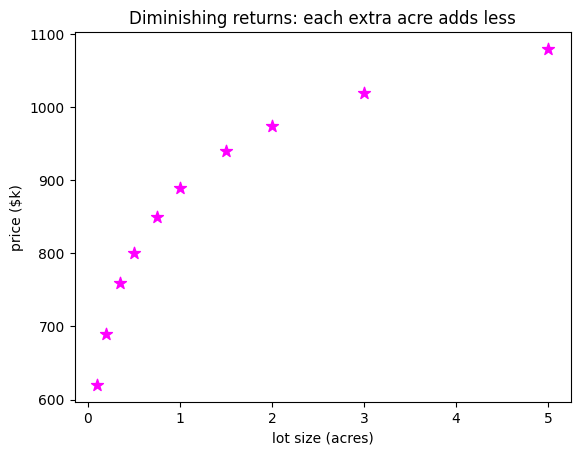

In [3]:
plt.scatter(df.lot_size, df.price, color='magenta', marker='*', s=80)
plt.xlabel('lot size (acres)')
plt.ylabel('price ($k)')
plt.title('Diminishing returns: each extra acre adds less')

Transform the input — fit a straight line on `(ln(lot_size), price)`.

In [4]:
ln_lot = np.log(df[['lot_size']].values)
reg = LinearRegression().fit(ln_lot, df['price'])

a = reg.coef_[0]
b = reg.intercept_
print(f'fit: price = {a:.4f} * ln(lot_size) + {b:.4f}')

fit: price = 119.8384 * ln(lot_size) + 888.0976


In [5]:
tst = pd.DataFrame(test)
tst['price'] = reg.predict(np.log(tst[['lot_size']].values))
tst

,lot_size,price
0,0.25,721.966277
1,0.80,861.356458
2,2.50,997.904488
3,4.00,1054.228991


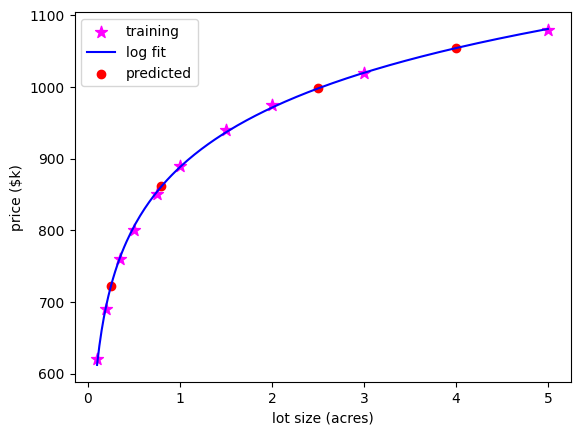

In [6]:
lot_grid = np.linspace(df.lot_size.min(), df.lot_size.max(), 200)
curve = a * np.log(lot_grid) + b

plt.scatter(df.lot_size, df.price, color='magenta', marker='*', s=80, label='training')
plt.plot(lot_grid, curve, color='blue', label='log fit')
plt.scatter(tst.lot_size, tst.price, color='red', label='predicted')
plt.xlabel('lot size (acres)')
plt.ylabel('price ($k)')
plt.legend()